### Subtask 1 - MULTILINGUAL TEXT CLASSIFICATION CHALLENGE - POLARIZATION DETECTION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import re

from torch.nn.functional import softmax

/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Loading data and data exploration


In [3]:
train_df = pd.read_csv('../../data/test_phase/subtask1/train/eng.csv')  
dev_df   = pd.read_csv('../../data/test_phase/subtask1/dev/eng.csv')
test_df  = pd.read_csv('../../data/test_phase/subtask1/test/eng.csv')

In [4]:
print("Training samples:", len(train_df))
print("Dev samples:", len(dev_df))
print("Test samples:", len(test_df))

Training samples: 3222
Dev samples: 160
Test samples: 1452


In [6]:
print(train_df.iloc[0])

id                   eng_973938b90b0ff5d87d35a582f83f5c89
text             is defending imperialism in the dnd chat
polarization                                            0
Name: 0, dtype: object


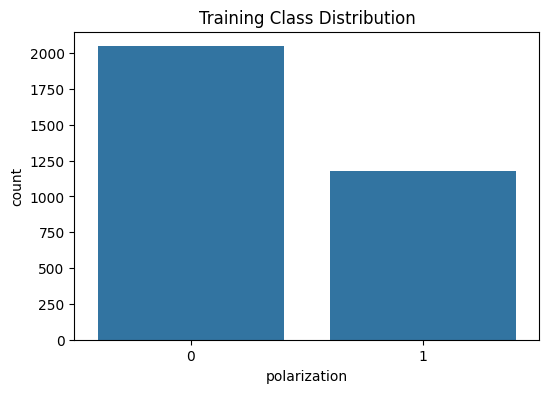

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="polarization", data=train_df)
plt.title("Training Class Distribution")
plt.show()

In [8]:
print("Training class counts:")
print(train_df['polarization'].value_counts())

Training class counts:
polarization
0    2047
1    1175
Name: count, dtype: int64


In [9]:
train_df.head()

,id,text,polarization
0,eng_973938b90b0ff5d87d35a582f83f5c89,is defending imperialism in the dnd chat,0
1,eng_07dfd4600426caca6e2c5883fcbea9ea,Still playing with this. I am now following Ra...,0
2,eng_f14519ff2302b6cd47712073f13bc461,.senate.gov Theres 3 groups out there Republic...,0
3,eng_e48b7e7542faafa544ac57b64bc80daf,"""ABC MD, David Anderson, said the additional f...",0
4,eng_7c581fb77bce8033aeba3d6dbd6273eb,"""bad people"" I have some conservative values s...",0


In [10]:
train_df.isnull().values

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       ...,
       [False, False, False],
       [False, False, False],
       [False, False, False]], shape=(3222, 3))

In [11]:

url_pattern = r"http\S+"

# rows that contain 
urls = train_df[train_df['text'].str.contains(url_pattern, regex=True, na=False)]

print(urls)

Empty DataFrame
Columns: [id, text, polarization]
Index: []


In [12]:
mention_pattern = r"@\w+"

mentions = train_df[train_df['text'].str.contains(mention_pattern, regex=True, na=False)]

print(mentions[:10])


                                       id  \
12   eng_393b1271c37b5f68ce43a7a44de16800   
37   eng_08955748de6580e14d14d5c42bca5bd5   
41   eng_540b6bca7b27467b180fab8291f62d9b   
75   eng_0499ce03f51dfef12815367906990389   
102  eng_a832d19fbcd38e84c863487cdf3179ef   
155  eng_97672cfe71eaf6138575b1ca8a4824f7   
194  eng_4529499d5af8af86d031167afe937aed   
324  eng_28b968f6a63bba8f61990dcaae4ce242   
340  eng_3ed8259f586ae27d1fb80bfbcb8cebe4   
373  eng_e5a37b8beb78a393ee5506eaf8b817c2   

                                                  text  polarization  
12   "Talks to reach a Gaza ceasefire and hostage r...             0  
37   A Marketing company out of San Diego is curren...             0  
41   A victory for voting rights in Wisconsin! Yest...             0  
75   Amid ceasefire push, Palestinians released fro...             0  
102  Appalling decision by Robert Fico to visit Put...             0  
155  Bloop "No thanks White South Africans turn dow...             0  
194  Ch

In [13]:
special_pattern = r"[^a-zA-Z0-9\s.,!?]"

special_chars = train_df[train_df['text'].str.contains(special_pattern, regex=True, na=False)]

print(special_chars)


                                        id  \
3     eng_e48b7e7542faafa544ac57b64bc80daf   
4     eng_7c581fb77bce8033aeba3d6dbd6273eb   
5     eng_bb7b41ffa6c56b52f8bbeb21a4c7aa77   
6     eng_3a6672eb8e74090ad8884ee4f3343dc0   
7     eng_2c77bd1f661480f247fad599ac99bd17   
...                                    ...   
3158  eng_4591c2fae023689f7af495b9831fe075   
3176  eng_25afc6495d561e56f6a38a836c01126a   
3186  eng_d5089fb455dc04709233c8ffe40163ac   
3205  eng_b5d4d49db28614ec464ce5887e4dc946   
3213  eng_96a94a561d064dd534f6a3f6cc6c5bcd   

                                                   text  polarization  
3     "ABC MD, David Anderson, said the additional f...             0  
4     "bad people" I have some conservative values s...             0  
5     "Enemy of the people" was a phrase coined and ...             0  
6     "He also voiced support for Elon Musk, Tommy R...             0  
7     "If you disagree with imperialism, youre a sup...             0  
...            

In [14]:
def preprocess_text(text):
    # lowercase
    text = text.lower()
    # remove mentions
    text = re.sub(r"@\w+", "", text)
    # remove special characters (keep basic)
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", "", text)
    return text

# apply preprocessing
train_df['text'] = train_df['text'].apply(preprocess_text)
dev_df['text']   = dev_df['text'].apply(preprocess_text)
test_df['text']  = test_df['text'].apply(preprocess_text)

In [15]:
special_pattern = r"[^a-zA-Z0-9\s.,!?]"

special_chars = train_df[train_df['text'].str.contains(special_pattern, regex=True, na=False)]

print(special_chars)

Empty DataFrame
Columns: [id, text, polarization]
Index: []


### Baseline Model: TF-IDF + Logistic Regression

In [16]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=500000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

baseline.fit(train_df['text'], train_df['polarization'])
dev_pred = baseline.predict(dev_df['text'])

print("baseline classification report:\n")
print(classification_report(dev_df['polarization'], dev_pred, digits=4))


baseline classification report:

              precision    recall  f1-score   support

           0     0.8090    0.7129    0.7579       101
           1     0.5915    0.7119    0.6462        59

    accuracy                         0.7125       160
   macro avg     0.7003    0.7124    0.7020       160
weighted avg     0.7288    0.7125    0.7167       160



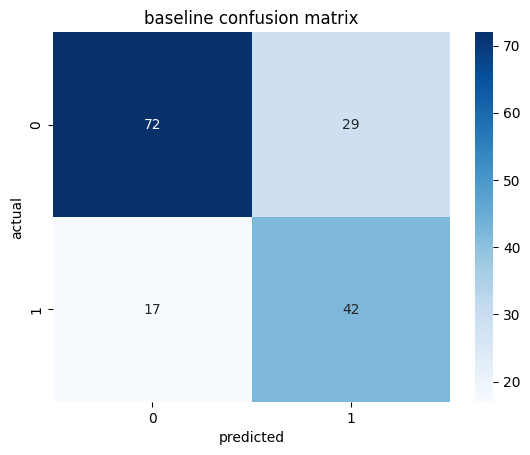

In [17]:
cm = confusion_matrix(dev_df['polarization'], dev_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("baseline confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

In [18]:
print("baseline macro F1:", f1_score(dev_df['polarization'], dev_pred, average="macro"))

baseline macro F1: 0.7020242914979757


### Transformer Model (XLM-RoBERTa)

In [45]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=2)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2105.22it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Con

In [46]:
def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(train_df)
dev_dataset   = Dataset.from_pandas(dev_df)

train_tok = train_dataset.map(tokenize, batched=True)
dev_tok   = dev_dataset.map(tokenize, batched=True)

train_tok = train_tok.rename_column("polarization", "labels")
dev_tok   = dev_tok.rename_column("polarization", "labels")

train_tok.set_format("torch", columns=["input_ids","attention_mask","labels"])
dev_tok.set_format("torch", columns=["input_ids","attention_mask","labels"])


Map: 100%|██████████| 160/160 [00:00<00:00, 34303.97 examples/s]


In [47]:
training_args = TrainingArguments(
    output_dir="polarization_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1"
)


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [48]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    f1 = f1_score(labels, preds, average="macro")
    return {"macro_f1": f1}

In [49]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=dev_tok,
    compute_metrics=compute_metrics
)

In [50]:
trainer.train()

/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.566510,0.628733
2,No log,0.500718,0.729345
3,0.524783,0.506070,0.770115


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.36it/s]
/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.67it/s]
/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'ro

TrainOutput(global_step=606, training_loss=0.504600990723462, metrics={'train_runtime': 198.8708, 'train_samples_per_second': 48.604, 'train_steps_per_second': 3.047, 'total_flos': 635807865277440.0, 'train_loss': 0.504600990723462, 'epoch': 3.0})

In [51]:
metrics = trainer.evaluate()
print("transformer evaluation metrics:", metrics)

/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


transformer evaluation metrics: {'eval_loss': 0.5060704350471497, 'eval_macro_f1': 0.7701149425287357, 'eval_runtime': 0.8497, 'eval_samples_per_second': 188.301, 'eval_steps_per_second': 11.769, 'epoch': 3.0}


### Retraining on full train dev, goal is final submission

In [26]:
full_df = pd.concat([train_df, dev_df])
full_dataset = Dataset.from_pandas(full_df)
full_tok = full_dataset.map(tokenize, batched=True)
full_tok = full_tok.rename_column("polarization", "labels")
full_tok.set_format("torch", columns=["input_ids","attention_mask","labels"])

trainer.train_dataset = full_tok
trainer.train()


Map: 100%|██████████| 3382/3382 [00:00<00:00, 47237.34 examples/s]
/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.386408,0.821429
2,No log,0.272120,0.912425
3,0.361613,0.278278,0.910341


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s]
/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.62it/s]
/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.61it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'ro

TrainOutput(global_step=636, training_loss=0.3403423657207369, metrics={'train_runtime': 208.466, 'train_samples_per_second': 48.67, 'train_steps_per_second': 3.051, 'total_flos': 667381191920640.0, 'train_loss': 0.3403423657207369, 'epoch': 3.0})

In [27]:
test_ds = Dataset.from_pandas(test_df).map(tokenize, batched=True)
test_ds.set_format("torch", columns=["input_ids","attention_mask"])

Map: 100%|██████████| 1452/1452 [00:00<00:00, 47353.10 examples/s]


In [28]:
pred = trainer.predict(test_ds)
test_pred = np.argmax(pred.predictions, axis=1)

/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [29]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "polarization": test_pred
})

submission.to_csv("submission.csv", index=False)

In [30]:
subbmision = pd.read_csv('./submission.csv')  

In [31]:
submission

,id,polarization
0,eng_0d46cf5c8e1f037159cfd6c9dcde03bb,0
1,eng_0676b42cc5e76f3a2b7cf3b562676fc1,0
2,eng_f3ce74f07a4cd9ee1926b87b40b78887,0
3,eng_9bb8d97251cc86cf5943c31be5f1b9a6,0
4,eng_755cacee0509beb4dc49f0fa1fd5d22f,0
...,...,...
1447,eng_f4858e4fdc8b57201e450bc0bf392a9a,0
1448,eng_d12f80a9177afca75e5db6221bcca576,1
1449,eng_7685f92f0afb27bbfdc38129ddbcfa9b,0
1450,eng_42a704fabf8851abd930242c7780f2b8,0


## END OF SUBMISSION

In [52]:
dev_df

,id,text,polarization,pred,confidence
0,eng_f66ca14d60851371f9720aaf4ccd9b58,god is with ukraine and zelensky,0,1,0.697655
1,eng_3a489aa7fed9726aa8d3d4fe74c57efb,"4 dems, 2 republicans luzerne county council s...",0,0,0.990345
2,eng_95770ff547ea5e48b0be00f385986483,abuse survivor recounts her struggles at ywca ...,0,0,0.982935
3,eng_2048ae6f9aa261c48e6d777bcc5b38bf,"after rwanda, another deportation camp disaster",0,0,0.965359
4,eng_07781aa88e61e7c0a996abd1e5ea3a20,another plea in trump election interference probe,0,0,0.972102
...,...,...,...,...,...
155,eng_9f170d76134d91a9aae08ec49a0eb1b1,wait what the fuck they did process my voter r...,0,0,0.597411
156,eng_3caf621f17c15e73ad88d1d58ace76e1,ballot stuffing by dems when republicans were ...,1,1,0.956667
157,eng_d735bda395a80ff9861c0ab78c5fb9a3,"prorussian propaganda. lies, lies, lies!",1,1,0.978696
158,eng_576cca5b3a10908cc024bc4c4c6e61b3,how are things going for the azov battalion si...,1,1,0.973583


In [53]:
pred_output = trainer.predict(dev_tok)

logits = pred_output.predictions
labels = pred_output.label_ids

probs = softmax(torch.tensor(logits), dim=1).numpy()
preds = np.argmax(probs, axis=1)

dev_df["pred"] = preds
dev_df["confidence"] = probs.max(axis=1)

/Users/davorangelov/VscodeProjects/semeval-polar-project/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [54]:
dev_df

,id,text,polarization,pred,confidence
0,eng_f66ca14d60851371f9720aaf4ccd9b58,god is with ukraine and zelensky,0,0,0.889256
1,eng_3a489aa7fed9726aa8d3d4fe74c57efb,"4 dems, 2 republicans luzerne county council s...",0,0,0.981531
2,eng_95770ff547ea5e48b0be00f385986483,abuse survivor recounts her struggles at ywca ...,0,0,0.979645
3,eng_2048ae6f9aa261c48e6d777bcc5b38bf,"after rwanda, another deportation camp disaster",0,0,0.672921
4,eng_07781aa88e61e7c0a996abd1e5ea3a20,another plea in trump election interference probe,0,1,0.828319
...,...,...,...,...,...
155,eng_9f170d76134d91a9aae08ec49a0eb1b1,wait what the fuck they did process my voter r...,0,0,0.900818
156,eng_3caf621f17c15e73ad88d1d58ace76e1,ballot stuffing by dems when republicans were ...,1,1,0.583750
157,eng_d735bda395a80ff9861c0ab78c5fb9a3,"prorussian propaganda. lies, lies, lies!",1,1,0.884728
158,eng_576cca5b3a10908cc024bc4c4c6e61b3,how are things going for the azov battalion si...,1,1,0.575900


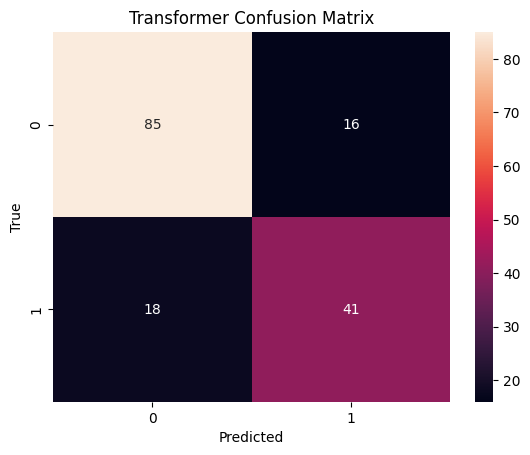

In [55]:
cm = confusion_matrix(labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Transformer Confusion Matrix")
plt.show()

In [56]:
print(classification_report(labels, preds, digits=4))

              precision    recall  f1-score   support

           0     0.8252    0.8416    0.8333       101
           1     0.7193    0.6949    0.7069        59

    accuracy                         0.7875       160
   macro avg     0.7723    0.7682    0.7701       160
weighted avg     0.7862    0.7875    0.7867       160



In [60]:
errors = dev_df[dev_df["polarization"] != dev_df["pred"]]
errors.sample(20)


,id,text,polarization,pred,confidence
118,eng_e5cfe9e96de0f4873a4a6dbfca573be2,every single article from msnbc reads like the...,1,0,0.859279
136,eng_5ee585bf8f98b28a7e65035db0204410,can trumpism be defeated? absolutely. heres how,0,1,0.558951
25,eng_af8597fa9be96fdfabb05c593476913c,is biden in trouble with democrats over gaza?,0,1,0.869871
76,eng_b91a56f542d0513d636a0a019b7726eb,oh right i forgot this movie had an illegal im...,0,1,0.697009
93,eng_b9cfff2304e5349d315bc474ce2899eb,i am getting my news from msnbc and the meidas...,1,0,0.976485
112,eng_5f408abc83c76617c0525e042a3ceb48,who gave the order to stop counting votes in t...,1,0,0.951542
154,eng_b01fd24fbfb6630edba40768157dbed3,dating apps are just capitalism pretending to ...,0,1,0.806799
125,eng_dbadd716608d71fb92621f7f8259f4e4,mayorkas secretly met with sorosfunded groups ...,1,0,0.945902
134,eng_2712f15ca491022233712e630d64d73d,asylum seekers in. oligarchs out.,1,0,0.524406
95,eng_2806bece99f0002047cc86a78a30a1d7,i guess steve didnt get the memo that the red ...,1,0,0.564552


XLM-RoBERTa struggles with pragmatic tone detection when context is missing.
Sarcasm is hard without conversational history.

In [64]:
high_conf_wrong = dev_df[
    (dev_df["polarization"] != dev_df["pred"]) &
    (dev_df["confidence"] > 0.9)
]

high_conf_wrong.sample(10)


,id,text,polarization,pred,confidence
125,eng_dbadd716608d71fb92621f7f8259f4e4,mayorkas secretly met with sorosfunded groups ...,1,0,0.945902
112,eng_5f408abc83c76617c0525e042a3ceb48,who gave the order to stop counting votes in t...,1,0,0.951542
74,eng_31268830d496fa2970b2ff9918b3b7ba,mike pence is such a nerd,0,1,0.937449
128,eng_2fd4484b6bab80971a96b2100e20966a,should run for gop press. lol,1,0,0.913706
91,eng_c12c886536597ecaddd1e94e922e8969,"go on, read it. show me the federal government...",1,0,0.948712
93,eng_b9cfff2304e5349d315bc474ce2899eb,i am getting my news from msnbc and the meidas...,1,0,0.976485
19,eng_00c797e70f1a2f50f1c59655f08581e1,hamas struck first and is a terrorist group. s...,0,1,0.926069
80,eng_325cd4d0e08485ec5693fcf15b14ff1f,this from mike pence! i mean im quoting mike p...,0,1,0.927661
104,eng_fd3ae133fa1ae5dac30d88c601d3171e,no! mail in ballots and early voting needs to ...,1,0,0.950472
132,eng_d841e099c41eb0fdd803e7c0a6109933,we build a wall around the red states and cele...,1,0,0.948266


### If model is VERY confident but wrong -> it learned misleading patterns.

In [66]:
low_conf_correct = dev_df[
    (dev_df["polarization"] == dev_df["pred"]) &
    (dev_df["confidence"] < 0.6)
]

low_conf_correct


,id,text,polarization,pred,confidence
109,eng_4cd9e7e11035bcacb2814a1817238e75,then why did you withhold military aid to them...,1,1,0.559244
110,eng_ebd69a723309a37d9b5f384a3cd5c87c,this is a massive scandal. it is time for impe...,1,1,0.541885
147,eng_c15194e3c8b4bba93b3d652340460ffd,"no, we need to hire here first. no one has a p...",0,0,0.533955
156,eng_3caf621f17c15e73ad88d1d58ace76e1,ballot stuffing by dems when republicans were ...,1,1,0.583750
158,eng_576cca5b3a10908cc024bc4c4c6e61b3,how are things going for the azov battalion si...,1,1,0.575900


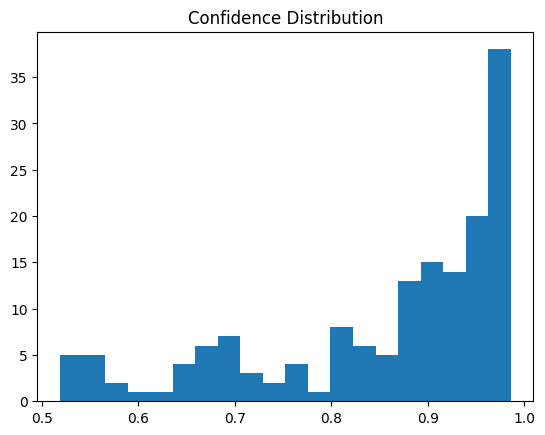

In [68]:
plt.hist(dev_df["confidence"], bins=20)
plt.title("Confidence Distribution")
plt.show()

most predictions are high confidence -> strong separation

### transformer evaluation metrics: {'eval_loss': 0.45443305373191833, 'eval_macro_f1': 0.7605916805608994, 'eval_runtime': 0.8389, 'eval_samples_per_second': 190.735, 'eval_steps_per_second': 11.921, 'epoch': 3.0}


### baseline macro F1: 0.7020242914979757


## The Transformer model is clearly better. With an ~8.3% relative improvement

## Why the Transformer Performs Better?
## - XLM-RoBERTa is pretrained on 100+ languages. It captures:Context, Syntax, Cross-lingual patterns, Semantic nuances